In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
dataset_dir = "flowers"

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4289 images belonging to 18 classes.
Found 1068 images belonging to 18 classes.


In [ ]:
convnext_model = ConvNeXtBase(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in convnext_model.layers:
    layer.trainable = False

num_classes = len(train_generator.class_indices)

model = models.Sequential([
    convnext_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 702s 2us/step


In [ ]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=valid_generator
)

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5365 - loss: 1.6278

C:\Users\Melih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


135/135 ━━━━━━━━━━━━━━━━━━━━ 1451s 11s/step - accuracy: 0.5371 - loss: 1.6255 - val_accuracy: 0.7996 - val_loss: 0.7584
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 1437s 11s/step - accuracy: 0.7356 - loss: 0.8710 - val_accuracy: 0.7809 - val_loss: 0.7107
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 1360s 10s/step - accuracy: 0.7577 - loss: 0.7662 - val_accuracy: 0.8118 - val_loss: 0.5694
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 1355s 10s/step - accuracy: 0.7875 - loss: 0.6732 - val_accuracy: 0.8371 - val_loss: 0.4918
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 1395s 10s/step - accuracy: 0.8079 - loss: 0.6179 - val_accuracy: 0.8521 - val_loss: 0.4868


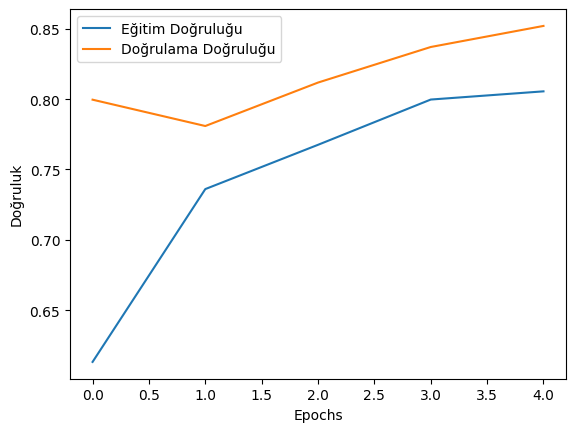

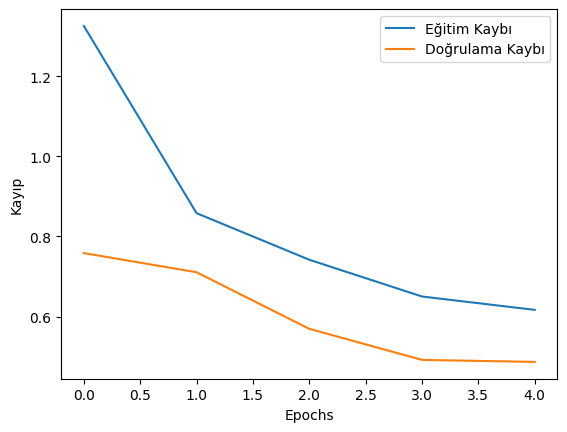

In [ ]:
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()
plt.show()

In [ ]:
test_generator = test_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Doğruluğu: {test_acc * 100:.2f}%")

Found 5357 images belonging to 18 classes.
168/168 ━━━━━━━━━━━━━━━━━━━━ 1472s 9s/step - accuracy: 0.8885 - loss: 0.3627
Test Doğruluğu: 88.24%


In [ ]:
model.save('ConvNext_Model.keras')